In [1]:
np.random.seed(23)
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1,cov_mat1,20)
df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2,cov_mat2,20)
df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df1['target'] = 0
df = pd.concat([df,df1],ignore_index=True)
df = df.sample(40)

In [2]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [5]:
!pip install plotly

  Using cached plotly-6.9.0-py3-none-any.whl.metadata (9.0 kB)
Using cached plotly-6.9.0-py3-none-any.whl (9.9 MB)


In [6]:
import plotly.express as px

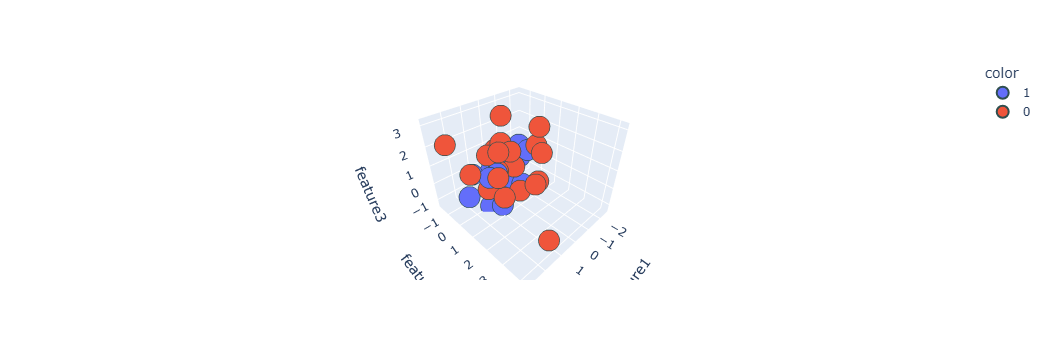

In [9]:
fig = px.scatter_3d(df,x=df['feature1'],y=df['feature2'],z=df['feature3'],color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,line=dict(width=2,color='DarkSlateGray')),
                  selector=dict(mode='markers'))
fig.show()

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [16]:
covariance_matrix = np.cov(df.iloc[:,0:3].T)
print("Covariance Matrix:\n",covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [57]:
eigen_values, eigen_vectors = np.linalg.eigh(covariance_matrix)

In [58]:
eigen_values

array([0.77774573, 0.94557084, 1.3536065 ])

In [59]:
eigen_vectors

array([[-0.47813384,  0.69363291, -0.53875915],
       [ 0.75461442,  0.01057596, -0.65608325],
       [-0.44938304, -0.72025103, -0.52848211]])

In [60]:
index = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[index]
eigen_vectors = eigen_vectors[:, index]

pc = eigen_vectors[:, :2]

In [61]:
transformed_df = np.dot(
    df.iloc[:, 0:3],
    pc
)

In [62]:
new_df = pd.DataFrame(
    transformed_df,
    columns=['PC1', 'PC2']
)

new_df['target'] = df['target'].values

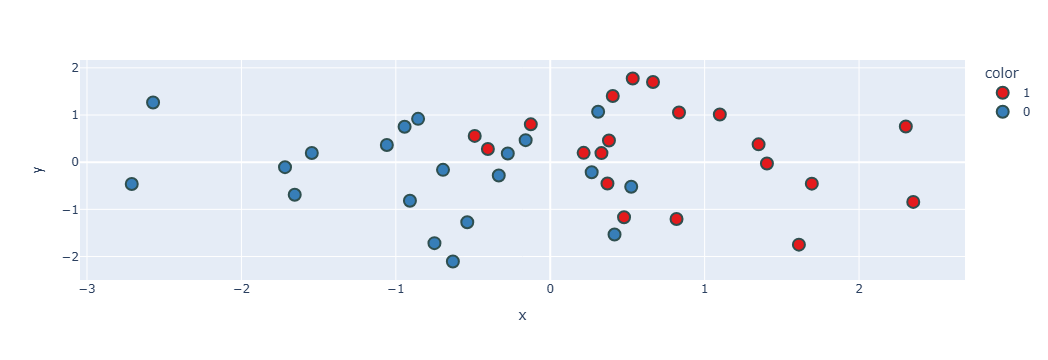

In [63]:
new_df['target'] = new_df['target'].astype(str)

fig = px.scatter(
    x=new_df['PC1'],
    y=new_df['PC2'],
    color=new_df['target'],
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(width=2, color='DarkSlateGrey')
    )
)

fig.show()

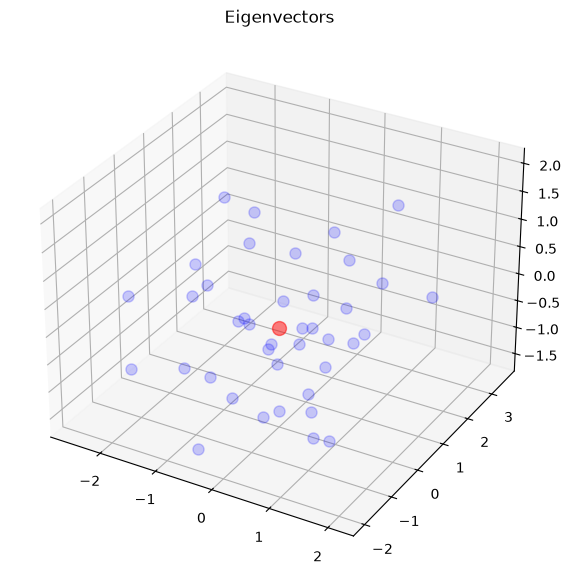

In [46]:
%matplotlib inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        FancyArrowPatch.draw(self, renderer)

    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
    ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
    a = Arrow3D([df['feature1'].mean(), v[0]], [df['feature2'].mean(), v[1]], [df['feature3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()
     

In [47]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j]])

In [52]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# (40,3)->(40,2)
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433+0.000000j,1.795862+0.000000j,1
1,1.056919+0.000000j,-0.212737+0.000000j,0
2,-0.271876+0.000000j,0.498222+0.000000j,1
3,-0.621586+0.000000j,0.023110+0.000000j,1
4,1.567286+0.000000j,1.730967+0.000000j,1


In [55]:
new_df['target'] = new_df['target'].astype('str')
fig =  px.scatter(x=new_df['PC1'],y=new_df['PC2'],color=new_df['target'],color_discrete_sequence=px.colors.qualitative.Set1)
fig.update_traces(marker=dict(size=12,line=dict(width=2,color='DarkSlateGrey')),selector=dict(mode='markers'))
fig.show()

TypeError: Object of type complex is not JSON serializable

In [56]:
new_df['target'] = new_df['target'].astype(str)

fig = px.scatter(
    x=new_df['PC1'],
    y=new_df['PC2'],
    color=new_df['target'],
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(
            width=2,
            color='DarkSlateGrey'
        )
    ),
    selector=dict(mode='markers')
)

fig.show()

TypeError: Object of type complex is not JSON serializable